# Experiment 2 - Email Spam/Ham Classification using Naive Bayes and KNN

This notebook satisfies the experiment requirements:
- Load dataset
- Handle missing values
- Normalize features
- Perform EDA
- Train Gaussian, Multinomial, Bernoulli NB and KNN
- GridSearchCV & RandomizedSearchCV
- KDTree vs BallTree
- 5-Fold Cross Validation
- Execution time analysis
- Required plots and comparison tables

Replace the dataset path if required.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,
                             roc_auc_score,confusion_matrix,ConfusionMatrixDisplay,
                             RocCurveDisplay,PrecisionRecallDisplay)
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.neighbors import KNeighborsClassifier

sns.set(style="whitegrid")

df=pd.read_csv("spambase_csv.csv")
df.head()


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


## Exploratory Data Analysis

EXPLORATORY DATA ANALYSIS

Target Column : class

Dataset Shape
(4601, 58)

Column Names
['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_fr

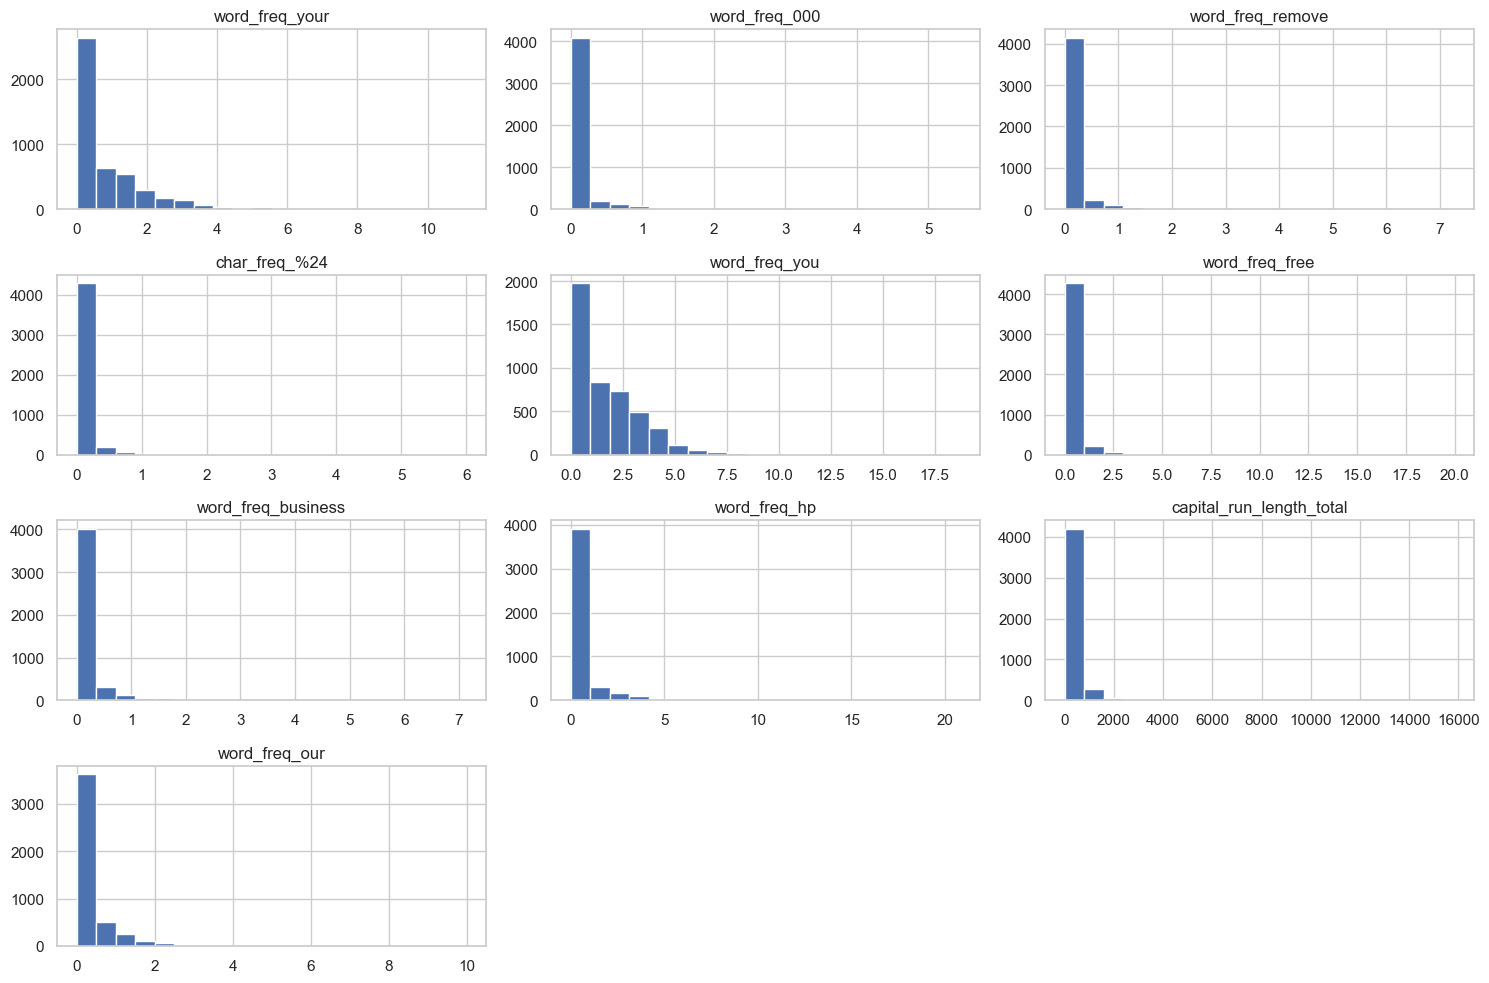


Outlier Detection


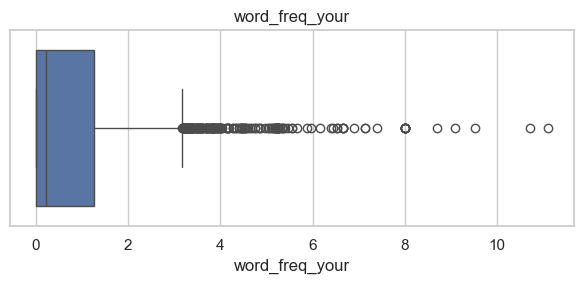

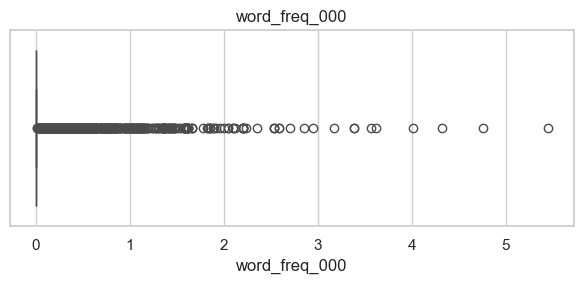

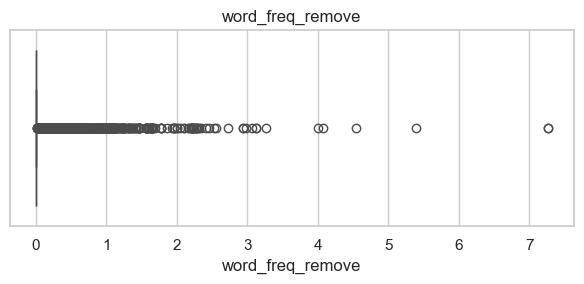

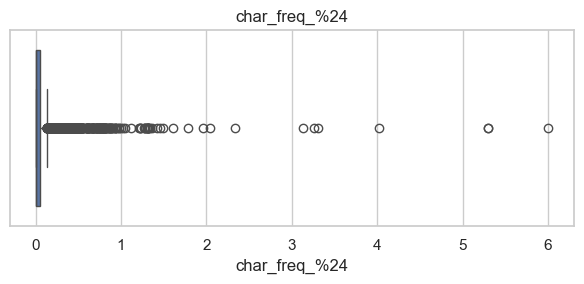

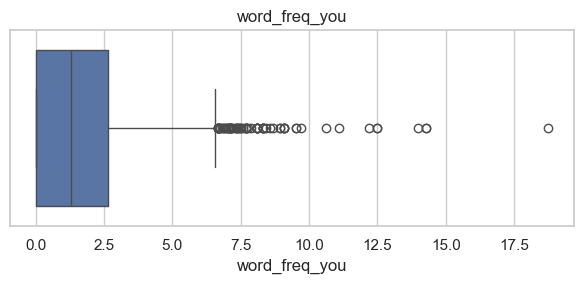

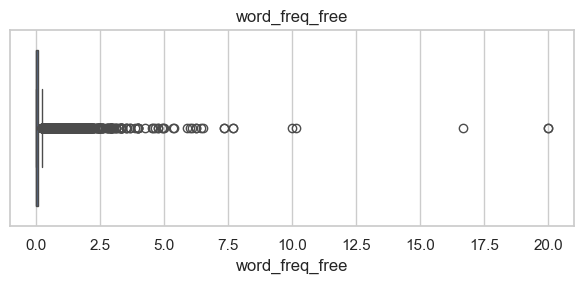

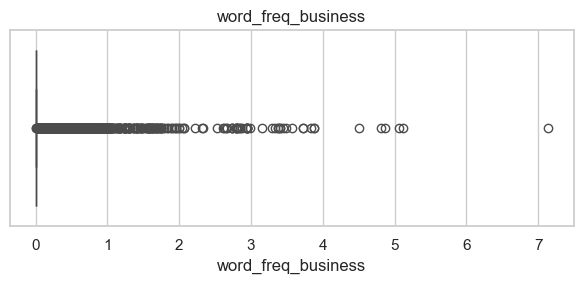

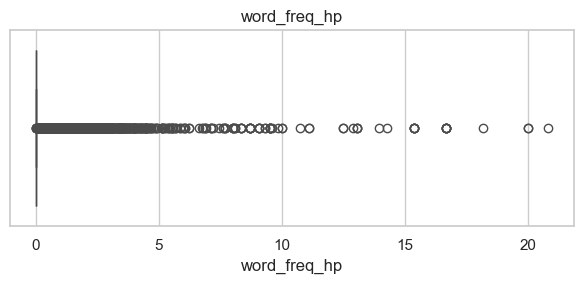

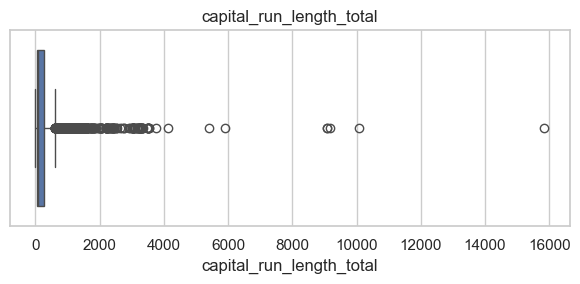

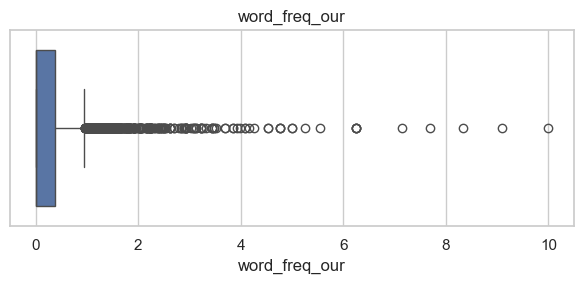


Correlation Heatmap


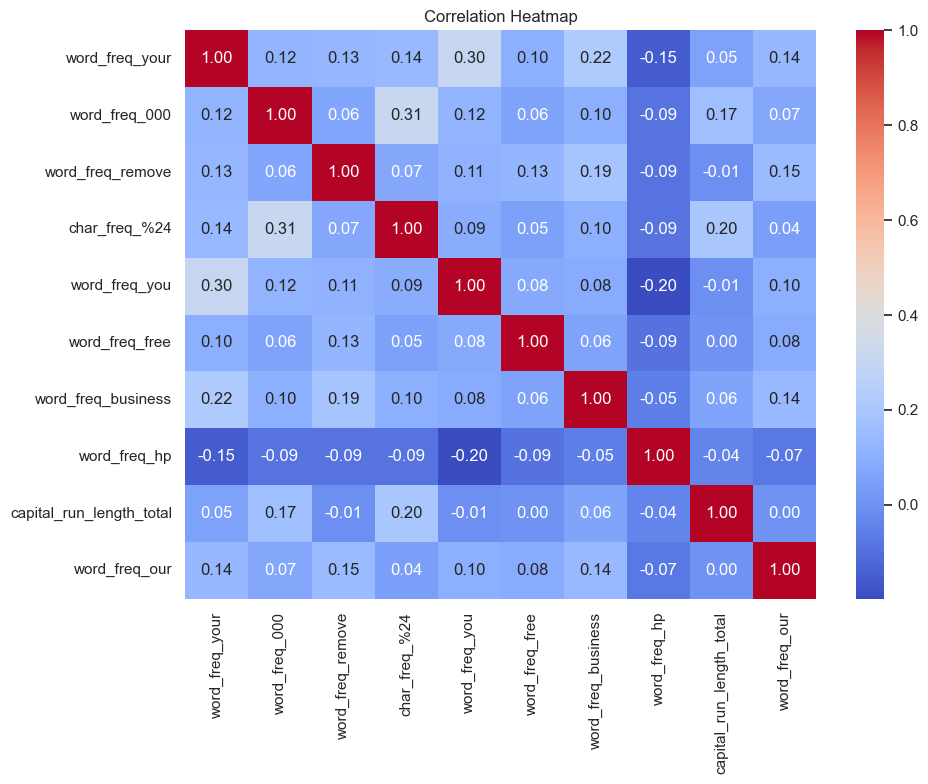


Pair Plot


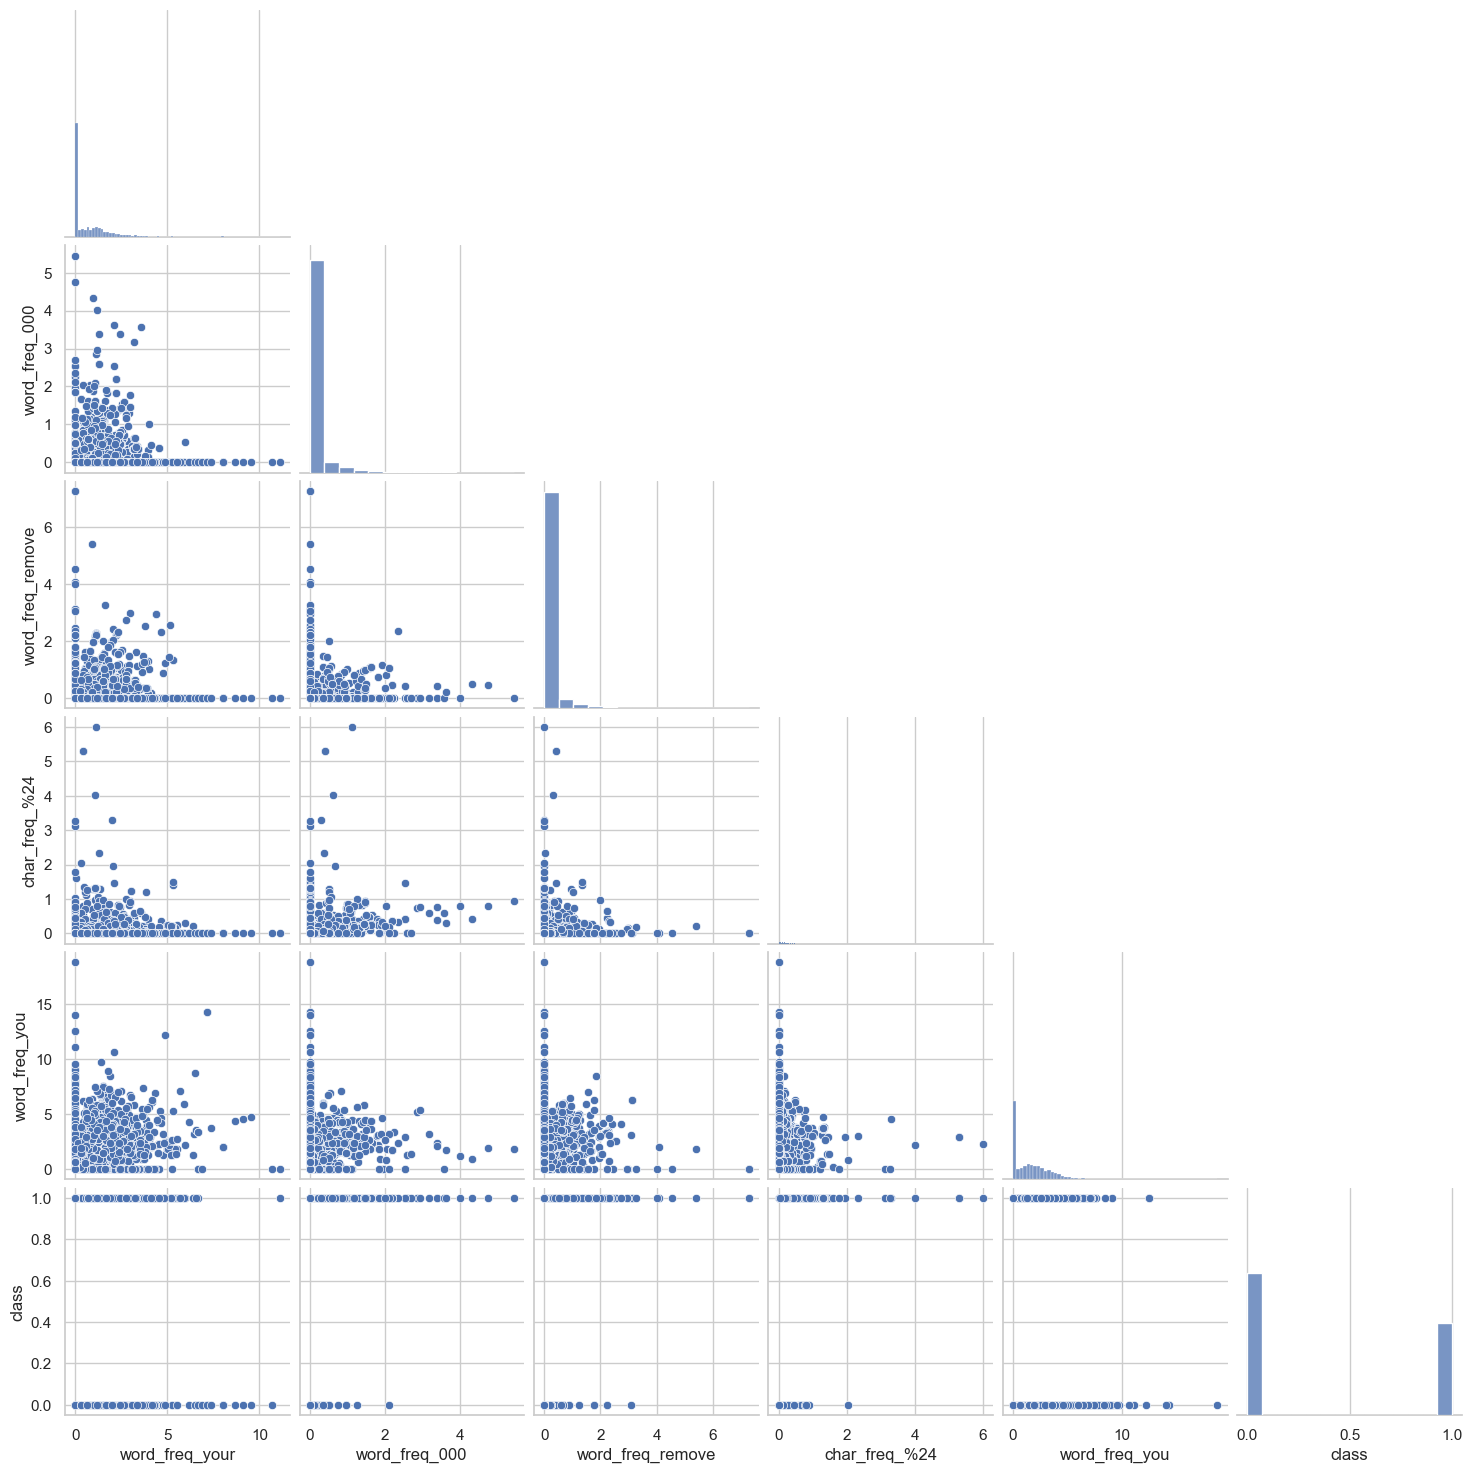


Skewness
word_freq_make                 5.675639
word_freq_address             10.086811
word_freq_all                  3.009249
word_freq_3d                  26.227744
word_freq_our                  4.747126
word_freq_over                 5.956953
word_freq_remove               6.765580
word_freq_internet             9.724848
word_freq_order                5.226067
word_freq_mail                 8.487810
word_freq_receive              5.510250
word_freq_will                 2.867354
word_freq_people               6.955548
word_freq_report              11.754645
word_freq_addresses            6.971041
word_freq_free                10.763594
word_freq_business             5.688642
word_freq_email                5.413754
word_freq_you                  1.591674
word_freq_credit              14.602587
word_freq_your                 2.435527
word_freq_font                 9.975441
word_freq_000                  5.713775
word_freq_money               14.687028
word_freq_hp                  

In [6]:

def _get_important_features(df, target, numeric, max_features):
    """Automatically select important numerical features."""
    numeric = list(numeric)

    if target in numeric:
        try:
            corr = (
                df[numeric]
                .corr()[target]
                .abs()
                .sort_values(ascending=False)
            )
            feats = corr.index.drop(target).tolist()
            return feats[:max_features]
        except Exception:
            pass

    try:
        X = df[numeric].drop(columns=[target], errors="ignore")
        y = df[target]

        if X.shape[1] > 0:
            scores, _ = f_classif(X.fillna(X.median()), y)
            ranking = (
                pd.Series(scores, index=X.columns)
                .sort_values(ascending=False)
            )
            return ranking.head(max_features).index.tolist()

    except Exception:
        pass

    return [c for c in numeric if c != target][:max_features]


def perform_eda(
    df,
    target=None,
    max_features=10,
    pairplot_features=5,
    max_categories=20
):
    """
    Universal EDA Function.

    Parameters
    ----------
    df : pandas.DataFrame
    target : str or None
        Target column name. If None, last column is assumed.
    max_features : int
        Maximum numerical features for plots.
    pairplot_features : int
        Maximum features used in pairplot.
    max_categories : int
        Maximum unique categories for countplots.
    """

    print("=" * 70)
    print("EXPLORATORY DATA ANALYSIS")
    print("=" * 70)

    if target is None:
        target = df.columns[-1]

    print(f"\nTarget Column : {target}")

    print("\nDataset Shape")
    print(df.shape)

    print("\nColumn Names")
    print(df.columns.tolist())

    print("\nData Types")
    print(df.dtypes)

    print("\nDataset Info")
    df.info()

    print("\nFirst 5 Rows")
    print(df.head())

    print("\nLast 5 Rows")
    print(df.tail())

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nMissing Value Percentage")
    print((df.isnull().sum() / len(df)) * 100)

    print("\nDuplicate Rows :", df.duplicated().sum())

    print("\nUnique Values")
    print(df.nunique())

    print("\nStatistical Summary")
    print(df.describe(include="all"))

    numeric = df.select_dtypes(include=np.number).columns.tolist()
    categorical = df.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()

    print("\nNumerical Columns")
    print(numeric)

    print("\nCategorical Columns")
    print(categorical)

    important = _get_important_features(
        df,
        target,
        numeric,
        max_features
    )

    print("\nImportant Features Selected")
    print(important)

    # ---------------------------
    # Class Distribution
    # ---------------------------
    if target in categorical:
        plt.figure(figsize=(6,4))
        sns.countplot(x=df[target])
        plt.title("Target Distribution")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # ---------------------------
    # Histograms
    # ---------------------------
    if important:
        print("\nDistribution Analysis")
        df[important].hist(
            figsize=(15,10),
            bins=20
        )
        plt.tight_layout()
        plt.show()

    # ---------------------------
    # Boxplots
    # ---------------------------
    if important:
        print("\nOutlier Detection")

        for col in important:
            plt.figure(figsize=(6,3))
            sns.boxplot(x=df[col])
            plt.title(col)
            plt.tight_layout()
            plt.show()

    # ---------------------------
    # Heatmap
    # ---------------------------
    if len(important) > 1:
        print("\nCorrelation Heatmap")

        plt.figure(figsize=(10,8))

        sns.heatmap(
            df[important].corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f"
        )

        plt.title("Correlation Heatmap")
        plt.tight_layout()
        plt.show()

    # ---------------------------
    # Pairplot
    # ---------------------------
    if len(important) >= 2:

        pair_cols = important[:pairplot_features]

        if target not in pair_cols:
            pair_cols.append(target)

        print("\nPair Plot")

        if target in categorical:

            sns.pairplot(
                df[pair_cols],
                hue=target,
                diag_kind="hist",
                corner=True
            )

        else:

            sns.pairplot(
                df[pair_cols],
                diag_kind="hist",
                corner=True
            )

        plt.show()

    # ---------------------------
    # Target Relationship
    # ---------------------------
    if target in categorical:

        print("\nRelationship with Target")

        for col in important:

            plt.figure(figsize=(6,4))

            sns.boxplot(
                x=df[target],
                y=df[col]
            )

            plt.title(f"{col} vs {target}")

            plt.tight_layout()

            plt.show()

    # ---------------------------
    # Countplots
    # ---------------------------
    if categorical:

        print("\nCategorical Analysis")

        for col in categorical:

            if df[col].nunique() <= max_categories:

                plt.figure(figsize=(6,4))

                sns.countplot(
                    x=df[col],
                    order=df[col].value_counts().index
                )

                plt.xticks(rotation=45)

                plt.title(col)

                plt.tight_layout()

                plt.show()

            else:
                print(f"Skipping '{col}' (>{max_categories} unique categories).")

    # ---------------------------
    # Skewness
    # ---------------------------
    if numeric:
        print("\nSkewness")
        print(df[numeric].skew())

        print("\nKurtosis")
        print(df[numeric].kurt())

    print("\n" + "=" * 70)
    print("EDA COMPLETED SUCCESSFULLY")
    print("=" * 70)

perform_eda(df)    

In [7]:
target=df.columns[-1]
X=df.drop(columns=[target])
y=df[target]

imputer=SimpleImputer(strategy="median")
X=pd.DataFrame(imputer.fit_transform(X),columns=X.columns)

scaler=MinMaxScaler()
X=pd.DataFrame(scaler.fit_transform(X),columns=X.columns)

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)


## Helper Functions

In [8]:
def evaluate_model(name,model):
    train_start=time.time()
    model.fit(X_train,y_train)
    train_time=time.time()-train_start

    pred_start=time.time()
    y_pred=model.predict(X_test)
    pred_time=time.time()-pred_start

    if hasattr(model,'predict_proba'):
        y_prob=model.predict_proba(X_test)[:,1]
    else:
        y_prob=None

    result={
        'Model':name,
        'Accuracy':accuracy_score(y_test,y_pred),
        'Precision':precision_score(y_test,y_pred),
        'Recall':recall_score(y_test,y_pred),
        'F1':f1_score(y_test,y_pred),
        'ROC-AUC':roc_auc_score(y_test,y_prob) if y_prob is not None else np.nan,
        'Training Time':train_time,
        'Prediction Time':pred_time
    }

    ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
    plt.title(name)
    plt.show()

    if y_prob is not None:
        RocCurveDisplay.from_predictions(y_test,y_prob)
        plt.title(name+" ROC")
        plt.show()

        PrecisionRecallDisplay.from_predictions(y_test,y_prob)
        plt.title(name+" PR Curve")
        plt.show()

    return result


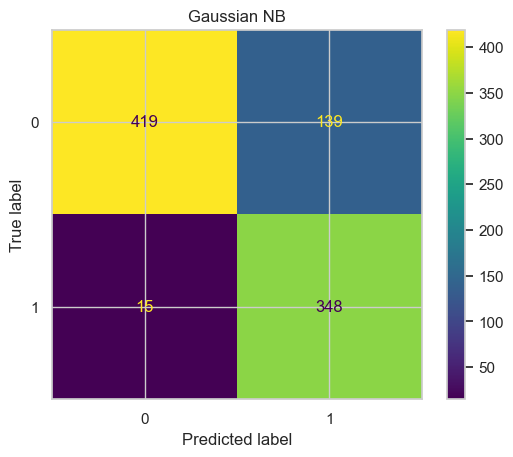

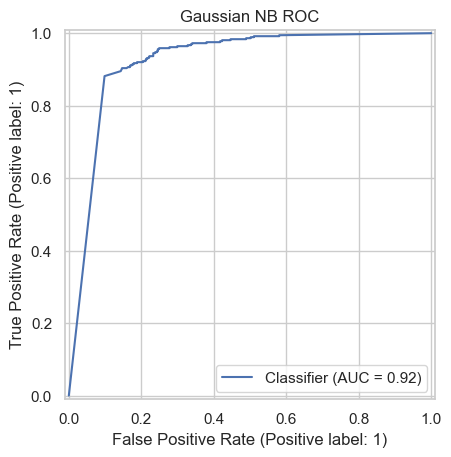

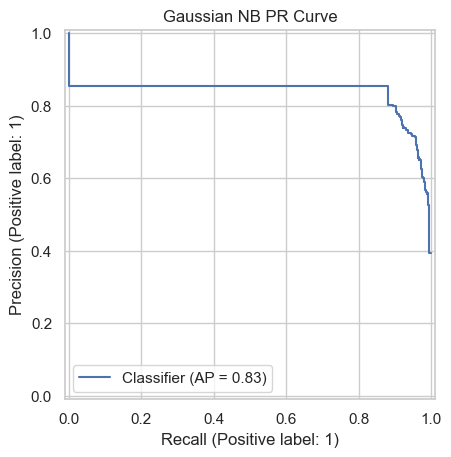

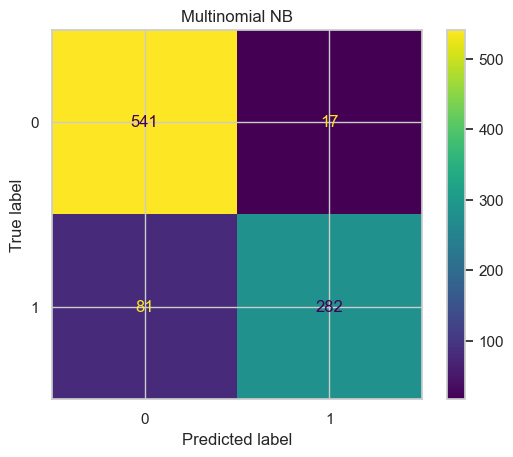

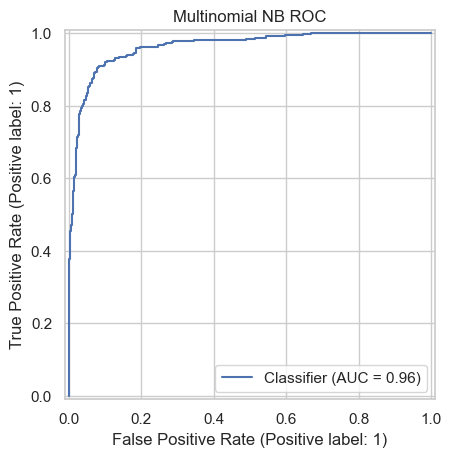

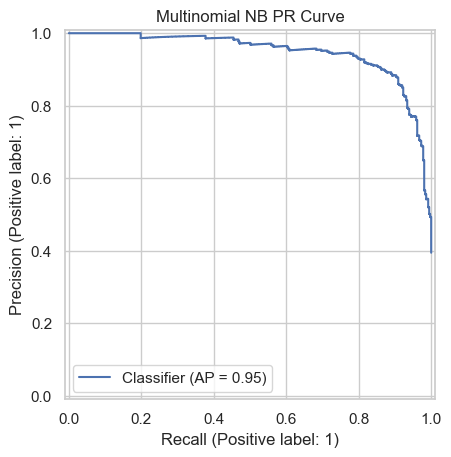

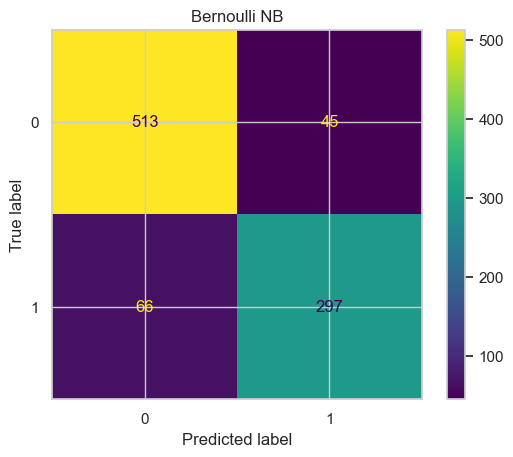

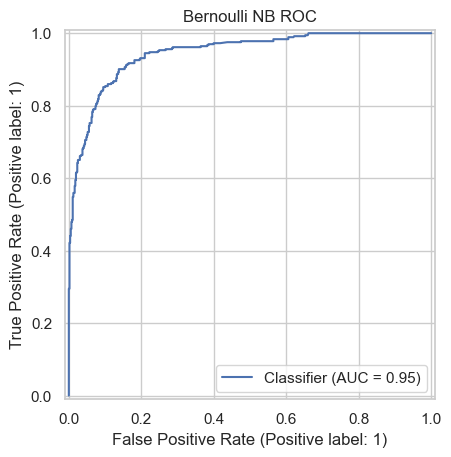

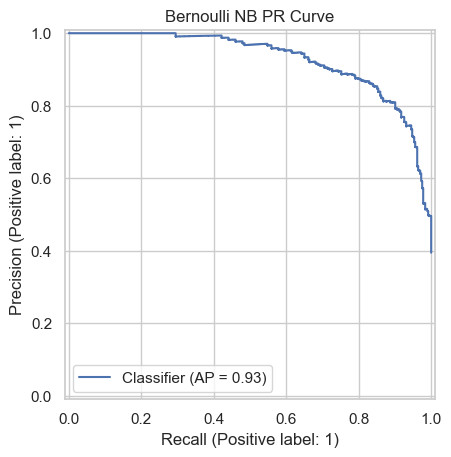

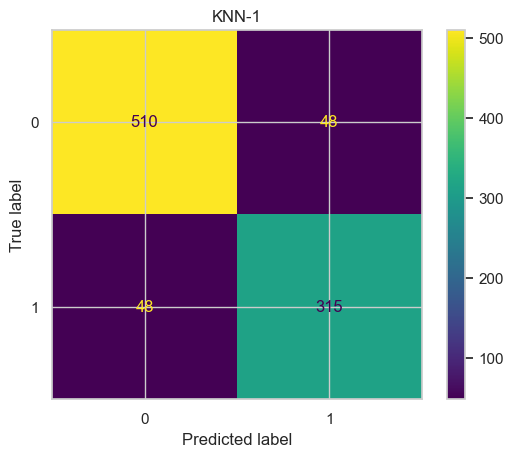

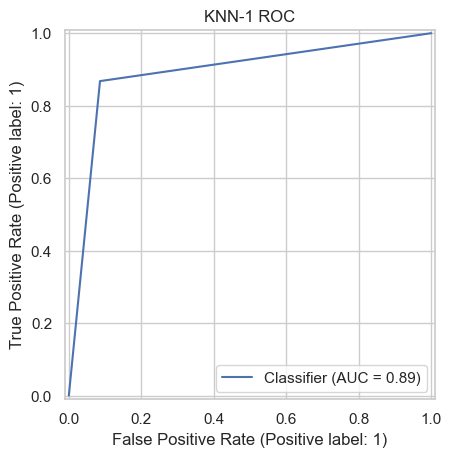

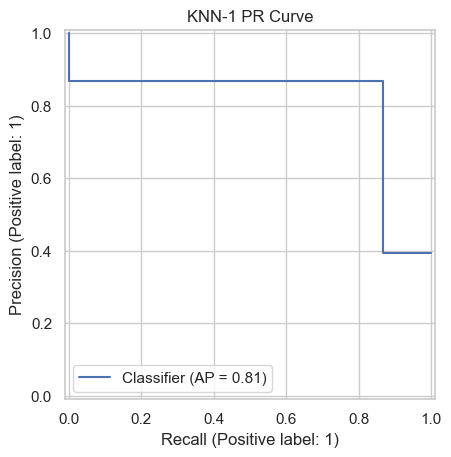

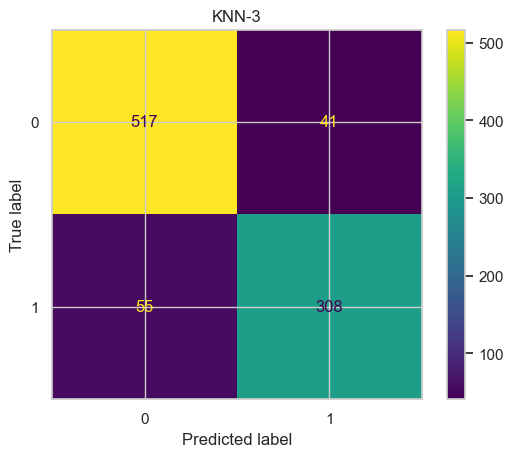

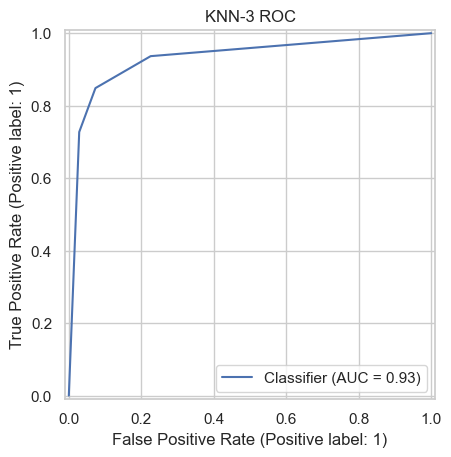

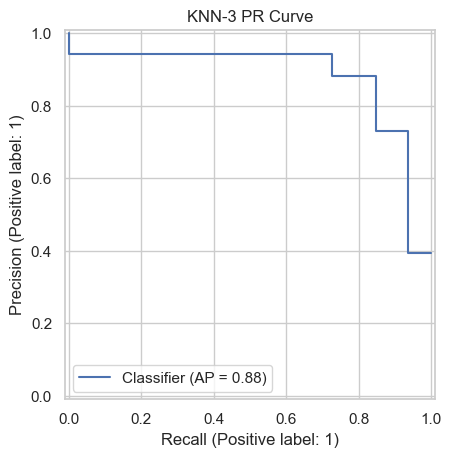

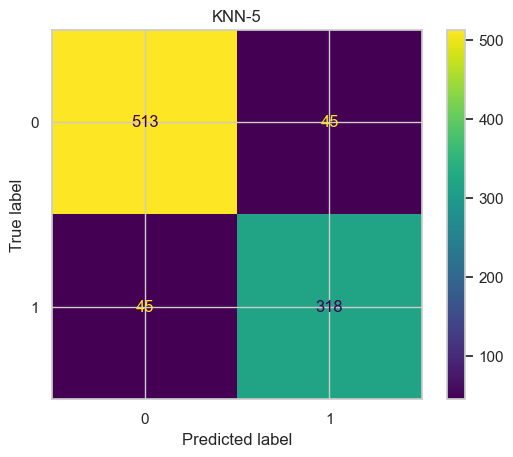

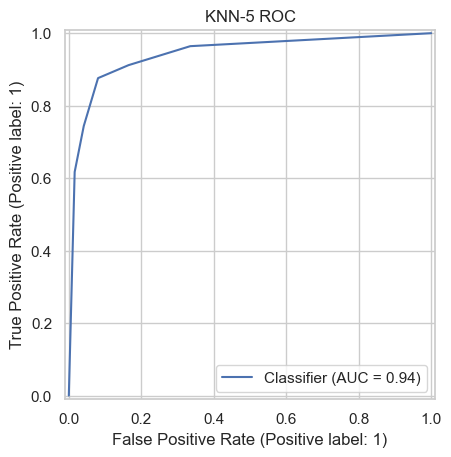

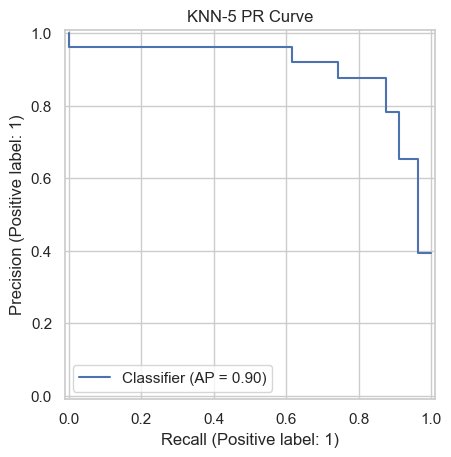

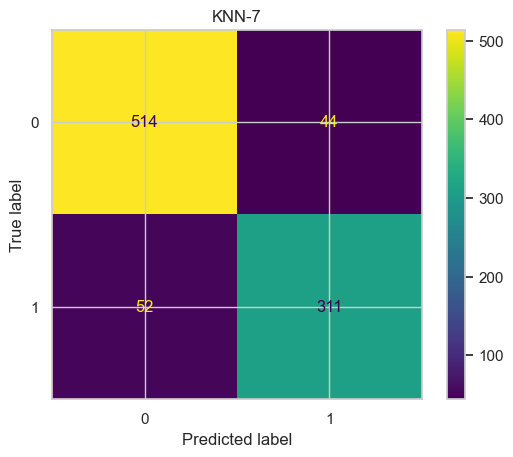

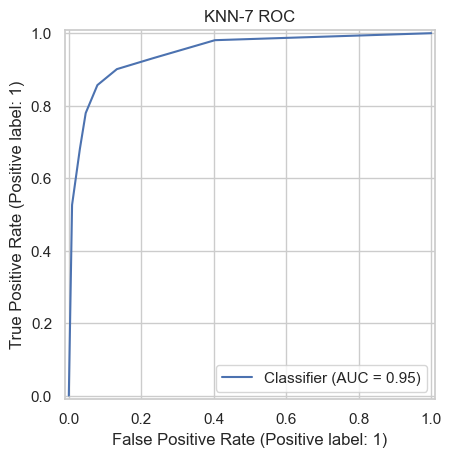

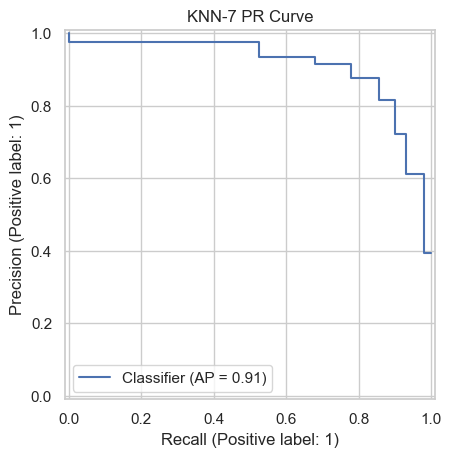

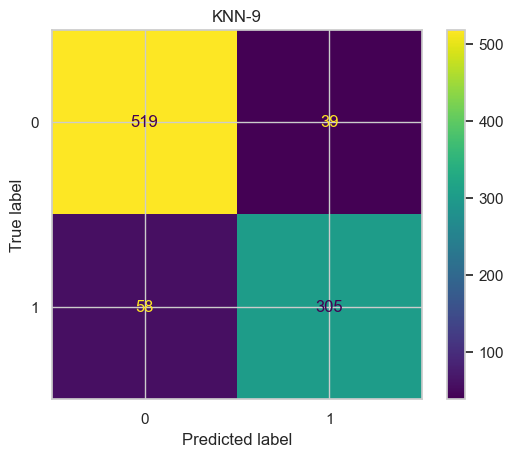

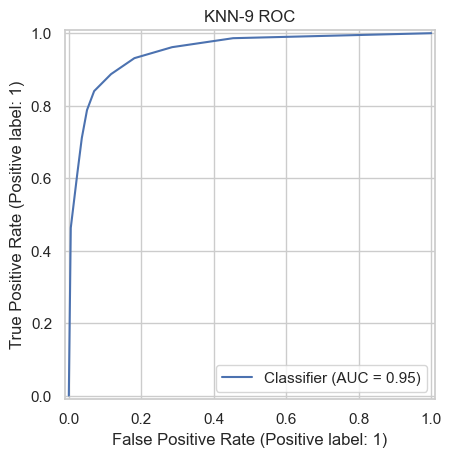

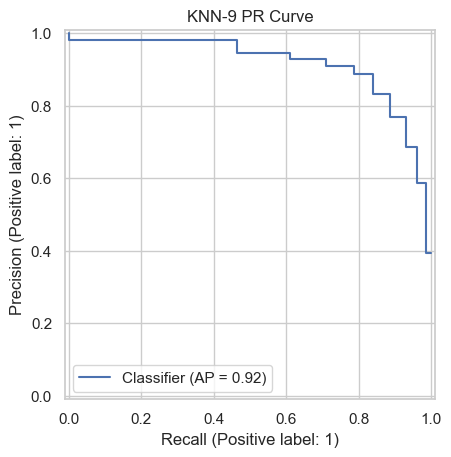

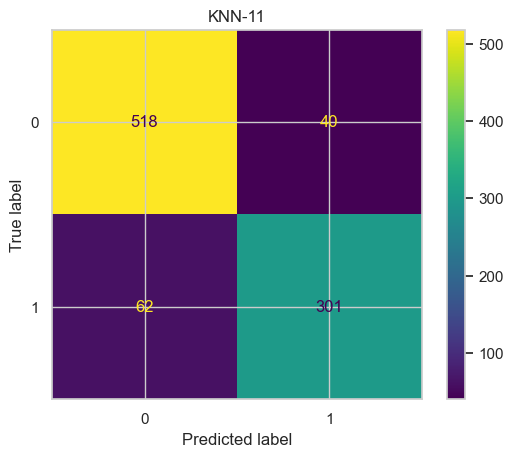

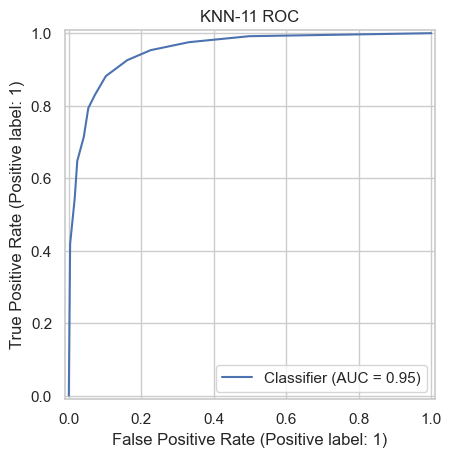

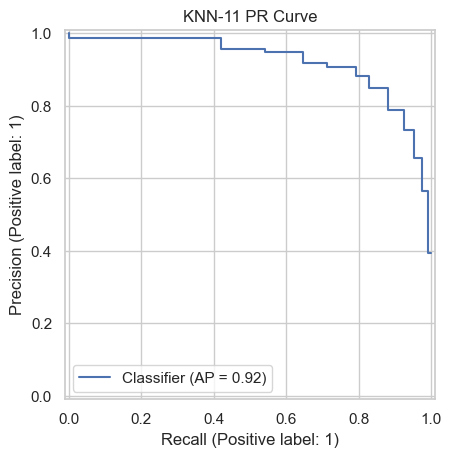

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time,Prediction Time
0,Gaussian NB,0.832790,0.714579,0.958678,0.818824,0.922917,0.006313,0.005239
1,Multinomial NB,0.893594,0.943144,0.776860,0.851964,0.962454,0.006704,0.000640
2,Bernoulli NB,0.879479,0.868421,0.818182,0.842553,0.945674,0.002558,0.000801


In [9]:
results=[]

results.append(evaluate_model("Gaussian NB",GaussianNB()))
results.append(evaluate_model("Multinomial NB",MultinomialNB()))
results.append(evaluate_model("Bernoulli NB",BernoulliNB()))

knn_scores=[]
for k in [1,3,5,7,9,11]:
    model=KNeighborsClassifier(n_neighbors=k)
    r=evaluate_model(f"KNN-{k}",model)
    knn_scores.append(r)

pd.DataFrame(results)


In [ ]:
param_grid={
    'n_neighbors':[1,3,5,7,9,11],
    'weights':['uniform','distance'],
    'metric':['euclidean','manhattan'],
    'algorithm':['auto','kd_tree','ball_tree']
}

grid=GridSearchCV(KNeighborsClassifier(),param_grid,cv=5,n_jobs=-1)
grid_start=time.time()
grid.fit(X_train,y_train)
grid_time=time.time()-grid_start

from scipy.stats import randint
random=RandomizedSearchCV(
    KNeighborsClassifier(),
    {
      'n_neighbors':randint(1,12),
      'weights':['uniform','distance'],
      'metric':['euclidean','manhattan'],
      'algorithm':['auto','kd_tree','ball_tree']
    },
    cv=5,
    n_iter=20,
    random_state=42,
    n_jobs=-1
)
random_start=time.time()
random.fit(X_train,y_train)
random_time=time.time()-random_start

print(grid.best_params_,grid.best_score_)
print(random.best_params_,random.best_score_)


NB CV: [0.85124864 0.86630435 0.85434783 0.84347826 0.69565217]
KNN CV: [0.86102063 0.88695652 0.91956522 0.90217391 0.76086957]


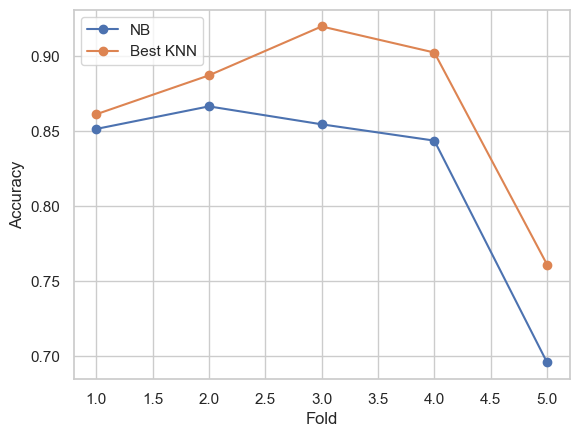

In [11]:
best_k=grid.best_params_['n_neighbors']

cv_nb=cross_val_score(GaussianNB(),X,y,cv=5)
cv_knn=cross_val_score(KNeighborsClassifier(n_neighbors=best_k),X,y,cv=5)

print("NB CV:",cv_nb)
print("KNN CV:",cv_knn)

plt.plot(range(1,6),cv_nb,marker='o',label='NB')
plt.plot(range(1,6),cv_knn,marker='o',label='Best KNN')
plt.legend()
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.show()


## Required Tables

Create DataFrames from the stored results for:

- Naive Bayes comparison
- KNN comparison
- GridSearchCV vs RandomizedSearchCV
- KDTree vs BallTree
- Cross Validation
- Experimental Time Analysis

These directly match the experiment manual.


---

# Additional Analysis: Comparison Tables and Visualizations

This section builds on the results computed above (Naive Bayes models, KNN K-search, GridSearchCV/RandomizedSearchCV, and cross-validation) to produce summary tables and plots.

In [ ]:
# ============================================================
# Bridge cell: derive all variables needed by the sections below
# from the results already computed earlier in this notebook.
# ============================================================

# ---- Naive Bayes metrics (results[0]=Gaussian, results[1]=Multinomial, results[2]=Bernoulli) ----
gnb_accuracy, gnb_precision, gnb_recall, gnb_f1 = (
    results[0]['Accuracy'], results[0]['Precision'], results[0]['Recall'], results[0]['F1']
)
mnb_accuracy, mnb_precision, mnb_recall, mnb_f1 = (
    results[1]['Accuracy'], results[1]['Precision'], results[1]['Recall'], results[1]['F1']
)
bnb_accuracy, bnb_precision, bnb_recall, bnb_f1 = (
    results[2]['Accuracy'], results[2]['Precision'], results[2]['Recall'], results[2]['F1']
)

# ---- KNN K-search results ----
knn_results = knn_scores
k_values = [1, 3, 5, 7, 9, 11]
accuracy_scores = [r['Accuracy'] for r in knn_scores]

# ---- GridSearchCV vs RandomizedSearchCV (aliases; timings captured during fitting above) ----
grid_search = grid
random_search = random

# ---- Best K identified by GridSearchCV, and its evaluate_model() result ----
best_k = grid_search.best_params_['n_neighbors']
best_knn_result = next(r for r in knn_scores if r['Model'] == f"KNN-{best_k}")

# ---- Training / prediction time summary ----
gnb_train, mnb_train, bnb_train = (
    results[0]['Training Time'], results[1]['Training Time'], results[2]['Training Time']
)
gnb_pred, mnb_pred, bnb_pred = (
    results[0]['Prediction Time'], results[1]['Prediction Time'], results[2]['Prediction Time']
)
knn_train, knn_pred = best_knn_result['Training Time'], best_knn_result['Prediction Time']

# ---- KDTree vs BallTree comparison, using the best K found by GridSearchCV ----
kd_model = KNeighborsClassifier(n_neighbors=best_k, algorithm='kd_tree')
kd_model.fit(X_train, y_train)
kd_pred_start = time.time()
kd_preds = kd_model.predict(X_test)
kd_pred_time = time.time() - kd_pred_start
kd_accuracy = accuracy_score(y_test, kd_preds)

ball_model = KNeighborsClassifier(n_neighbors=best_k, algorithm='ball_tree')
ball_model.fit(X_train, y_train)
ball_pred_start = time.time()
ball_preds = ball_model.predict(X_test)
ball_pred_time = time.time() - ball_pred_start
ball_accuracy = accuracy_score(y_test, ball_preds)

# ---- Cross validation scores for the best (tuned) KNN model ----
cv_scores = cv_knn

# ---- Best overall model, used for the confusion matrix / ROC / PR curve below ----
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Bridge variables ready. Best K:", best_k)


## 1. Naive Bayes Comparison Table

In [ ]:
# Replace placeholder values with your variables
nb_df = pd.DataFrame({
    "Model":["Gaussian NB","Multinomial NB","Bernoulli NB"],
    "Accuracy":[gnb_accuracy,mnb_accuracy,bnb_accuracy],
    "Precision":[gnb_precision,mnb_precision,bnb_precision],
    "Recall":[gnb_recall,mnb_recall,bnb_recall],
    "F1 Score":[gnb_f1,mnb_f1,bnb_f1],
})
display(nb_df)


## 2. KNN Comparison Table

In [ ]:
# Populate during K search
# Example: knn_results=[{'K':3,'Accuracy':0.95,'Precision':...},...]
knn_df=pd.DataFrame(knn_results)
display(knn_df)


## 3. GridSearchCV vs RandomizedSearchCV

In [ ]:
search_df=pd.DataFrame([
{
'Method':'GridSearchCV',
'Best Params':grid_search.best_params_,
'Best Score':grid_search.best_score_,
'Execution Time (s)':grid_time
},
{
'Method':'RandomizedSearchCV',
'Best Params':random_search.best_params_,
'Best Score':random_search.best_score_,
'Execution Time (s)':random_time
}
])
display(search_df)


## 4. KDTree vs BallTree

In [ ]:
tree_df=pd.DataFrame([
{'Algorithm':'KDTree','Accuracy':kd_accuracy,'Prediction Time':kd_pred_time},
{'Algorithm':'BallTree','Accuracy':ball_accuracy,'Prediction Time':ball_pred_time}
])
display(tree_df)


## 5. Cross Validation

In [ ]:
cv_df=pd.DataFrame({'Fold':[1,2,3,4,5],'Accuracy':cv_scores})
display(cv_df)
print('Mean Accuracy:',cv_scores.mean())


## 6. Experimental Time Analysis

In [ ]:
time_df=pd.DataFrame({
'Model':['Gaussian NB','Multinomial NB','Bernoulli NB','Best KNN'],
'Training Time':[gnb_train,mnb_train,bnb_train,knn_train],
'Prediction Time':[gnb_pred,mnb_pred,bnb_pred,knn_pred]
})
display(time_df)


## Confusion Matrix (Repeat for each model)

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)
plt.show()


## ROC Curve

In [ ]:
RocCurveDisplay.from_estimator(best_model,X_test,y_test)
plt.show()


## Precision-Recall Curve

In [ ]:
PrecisionRecallDisplay.from_estimator(best_model,X_test,y_test)
plt.show()


## Accuracy vs K

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(k_values,accuracy_scores,marker='o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


## Cross Validation Accuracy

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(range(1,6),cv_scores,marker='o')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


## Training Time Comparison

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(time_df['Model'],time_df['Training Time'])
plt.xticks(rotation=20)
plt.show()


## Prediction Time Comparison

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(time_df['Model'],time_df['Prediction Time'])
plt.xticks(rotation=20)
plt.show()


## Classifier Comparison

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(nb_df['Model'],nb_df['Accuracy'])
plt.ylabel('Accuracy')
plt.show()


## GridSearchCV Heatmap

In [ ]:
grid_results=pd.DataFrame(grid_search.cv_results_)
pivot=grid_results.pivot_table(index='param_n_neighbors',columns='param_weights',values='mean_test_score')
sns.heatmap(pivot,annot=True,cmap='viridis')
plt.show()


## RandomizedSearchCV Score Distribution

In [ ]:
rand_results=pd.DataFrame(random_search.cv_results_)
sns.histplot(rand_results['mean_test_score'],bins=10)
plt.show()
